# **4. Modelado Benchmark**


En esta sección se implementan y comparan distintos modelos de **aprendizaje supervisado** con el fin de establecer un *benchmark* de desempeño sobre el conjunto de datos procesado.  
El propósito de este análisis es evaluar cómo distintos algoritmos clásicos responden al mismo problema de predicción, identificando sus fortalezas, debilidades y sensibilidad frente a las características del dataset.

Se trabajará con un conjunto de modelos que cubren tanto enfoques lineales como no lineales:

- **Regresión Logística** 
- **K-Nearest Neighbors (KNN)**
- **Naive Bayes**
- **Árbol de Decisión**
- **Random Forest**
- **XGBoost**
- **Support Vector Machine (SVM – LinearSVC)**

Cada modelo se entrena utilizando un **pipeline de preprocesamiento**, que incluye imputación de valores faltantes, codificación de variables categóricas y estandarización de variables numéricas.  
Además, se realiza una **búsqueda de hiperparámetros (GridSearchCV)** y **validación cruzada estratificada** para garantizar la robustez de los resultados y evitar el sobreajuste.



**Objetivo del modelado benchmark**

- Construir una línea base de comparación entre los distintos algoritmos.  
- Analizar métricas de desempeño como **Accuracy, Recall, F1-score y AUC-ROC**.  
- Identificar los modelos con mayor capacidad predictiva antes de aplicar técnicas de balanceo, optimización o interpretabilidad.  
- Sentar las bases para el proceso de **tuning avanzado** e **interpretación de resultados** que se desarrollará en las siguientes secciones.


**Librerias**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import time
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
                             mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, precision_score, recall_score
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
import numpy as np

**Carga de base de datos**

In [2]:
df= pd.read_csv('df_limpio.csv')

**Verificacion de nulos**

In [3]:
df.isnull().sum()

estado                 0
sexo                   0
salud_general          0
dias_salud_fisica      0
dias_salud_mental      0
ultimo_chequeo         0
actividades_fisicas    0
horas_sueño            0
dientes_removidos      0
ataque_cardiaco        0
angina                 0
ACV                    0
asma                   0
cancer_piel            0
EPOC                   0
trastorno_depre        0
enfermedad_riñon       0
artritis               0
diabetes               0
sordo_semisordo        0
ciego_semiciego        0
dif_concentracion      0
dif_caminar            0
dif_vestirduchar       0
dif_encargo            0
estado_fumador         0
uso_cigarroelect       0
escaner_torax          0
categoria_etnica       0
categoria_edad         0
altura_metros          0
peso_kilos             0
bmi                    0
bebedor_alcohol        0
prueba_VIH             0
gripa_vac              0
pneumo                 0
tetanos                0
alto_riesgo_ap         0
covid                  0


## **Visualización del Dataset**

In [4]:
df.head()

,estado,sexo,salud_general,dias_salud_fisica,dias_salud_mental,ultimo_chequeo,actividades_fisicas,horas_sueño,dientes_removidos,ataque_cardiaco,...,altura_metros,peso_kilos,bmi,bebedor_alcohol,prueba_VIH,gripa_vac,pneumo,tetanos,alto_riesgo_ap,covid
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


## **Eliminar variable no relevantes para el modelo**

In [5]:
cols_drop = [
    # Moderadamente relevantes
    "sexo", "cancer_piel", "escaner_torax",
    "gripa_vac", "pneumo", "tetanos", "covid",
    
    # Poco relevantes o indirectas
    "estado", "ciego_semiciego", "sordo_semisordo",
    "dif_concentracion", "dif_caminar", "dif_vestirduchar",
    "dif_encargo", "prueba_VIH"
]

# Eliminar columnas
df = df.drop(columns=cols_drop)

## **Partición de Datos antes de Tratar para evitar ``Data Leakage``**

In [6]:
# Separar X (features) e y (target)
X = df.drop(columns='diabetes')
y = df['diabetes']

# === Split estratificado ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(include="object").columns

## **Preprocesamiento de Datos**

### **Análisis de Outliers**

In [7]:

class ManejoAtipicos(BaseEstimator, TransformerMixin):
    def __init__(self, metodo="iqr", estrategia="winsorizar"):
        
        self.metodo = metodo
        self.estrategia = estrategia
        self.limites_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            if self.metodo == "iqr":
                Q1 = X[col].quantile(0.25)
                Q3 = X[col].quantile(0.75)
                IQR = Q3 - Q1
                lim_inf = Q1 - 1.5 * IQR
                lim_sup = Q3 + 1.5 * IQR
            elif self.metodo == "percentil":
                lim_inf = X[col].quantile(0.01)
                lim_sup = X[col].quantile(0.99)
            else:
                raise ValueError("Método no soportado")

            self.limites_[col] = (lim_inf, lim_sup)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            lim_inf, lim_sup = self.limites_[col]
            if self.estrategia == "eliminar":
                X = X[(X[col] >= lim_inf) & (X[col] <= lim_sup)]
            elif self.estrategia == "winsorizar":
                X[col] = np.where(X[col] < lim_inf, lim_inf, X[col])
                X[col] = np.where(X[col] > lim_sup, lim_sup, X[col])
        return X.reset_index(drop=True)

In [8]:
X_train_num = X_train[num_cols]
X_test_num  = X_test[num_cols]

# Instanciar el manejador de atípicos
atipicos= ManejoAtipicos(metodo="iqr", estrategia="winsorizar")

# Ajustar solo con TRAIN
atipicos.fit(X_train_num)

# Transformar TRAIN y TEST
X_train_num_sin_atip = atipicos.transform(X_train_num)
X_test_num_sin_atip  = atipicos.transform(X_test_num)

In [9]:
for col in num_cols:
    X_train.loc[:, col] = X_train_num_sin_atip[col].values
    X_test.loc[:, col]  = X_test_num_sin_atip[col].values

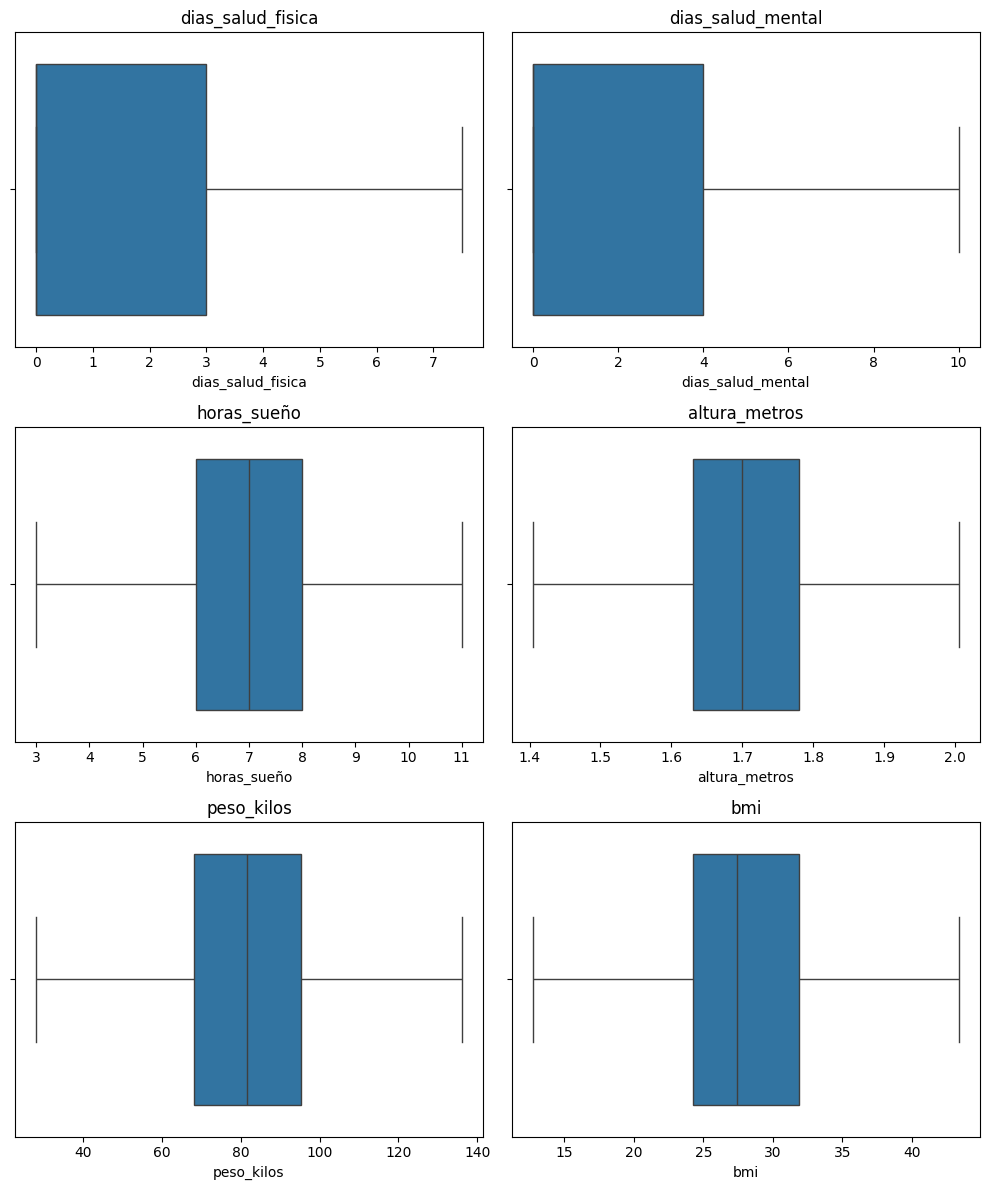

In [10]:
plots_per_row = 2
n = len(num_cols)
rows = math.ceil(n/plots_per_row)
fig, axes = plt.subplots(rows, plots_per_row, figsize=(5*plots_per_row,4*rows))
for i, col in enumerate(num_cols):
  ax = axes.flatten()[i]
  sns.boxplot(x=X_train[col], ax=ax).set_title(col)
for ax in axes.flatten()[n:]: fig.delaxes(ax)
plt.tight_layout()

Después del tratamiento de outliers podemos observar que los datos se visualizan más compactos y con una distribución manejable.

In [11]:
X.to_csv("df_sin_atipicos.csv", index=False)
y.to_frame(name='diabetes').to_csv("y_sin_atipicos.csv", index=False)

# Guardar conjuntos de entrenamiento y prueba
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

# Convertir y_train / y_test a DataFrame para que tengan nombre de columna
y_train.to_frame(name='diabetes').to_csv("y_train.csv", index=False)
y_test.to_frame(name='diabetes').to_csv("y_test.csv", index=False)

## **Modelo de `Regresión Logística`**

In [12]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline


# === Preprocesador y Pipeline ===
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="drop"
)
pipe_reglog= Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced"))
])



El preprocesador definido mediante `ColumnTransformer` aplica transformaciones específicas a los distintos tipos de variables: las numéricas se escalan con `StandardScaler()` para normalizar su rango y mejorar la estabilidad del modelo, mientras que las categóricas se convierten en variables binarias con `OneHotEncoder(drop="first", handle_unknown="ignore")`, evitando multicolinealidad y errores ante categorías nuevas. Luego, este preprocesamiento se integra con la Regresión Logística dentro de un `Pipeline`, que automatiza todo el flujo de trabajo desde la limpieza y transformación de los datos hasta el entrenamiento del modelo. La regresión se configuró con `max_iter=1000` para garantizar la convergencia y `class_weight="balanced"` para compensar posibles desbalances de clases. Este enfoque asegura reproducibilidad, evita fugas de información (*data leakage*) y facilita la validación cruzada y el ajuste de hiperparámetros en un solo proceso coherente.


In [13]:
# === Entrenar ===
start_time = time.time()
pipe_reglog.fit(X_train, y_train)
train_time = time.time() - start_time

In [14]:
train_score = pipe_reglog.score(X_train, y_train)
test_score = pipe_reglog.score(X_test, y_test)
print("Training set score: {:.3f}".format(train_score))
print("Test set score: {:.3f}".format(test_score))


Training set score: 0.728
Test set score: 0.728


El resultado muestra los puntajes de desempeño del modelo en los conjuntos de entrenamiento y prueba.  
Un **Training set score de 0.728** indica que el modelo logra predecir correctamente el 72.8 % de las observaciones en los datos de entrenamiento, mientras que el **Test set score de 0.728** refleja un desempeño prácticamente igual (72.8 %) en datos nuevos que el modelo no había visto. Esta similitud entre ambos valores sugiere que el modelo **generaliza bien**: no está sobreajustado (overfitting) ni subajustado (underfitting), sino que mantiene un equilibrio adecuado entre ajuste al entrenamiento y capacidad predictiva sobre datos desconocidos. En otras palabras, la Regresión Logística logró un nivel de rendimiento estable y consistente, lo cual es una señal positiva en términos de su capacidad de generalización.


== Métricas con threshold ==
Accuracy: 0.7282125630047152

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.72      0.82     63661
           1       0.31      0.77      0.44     10143

    accuracy                           0.73     73804
   macro avg       0.63      0.75      0.63     73804
weighted avg       0.86      0.73      0.77     73804



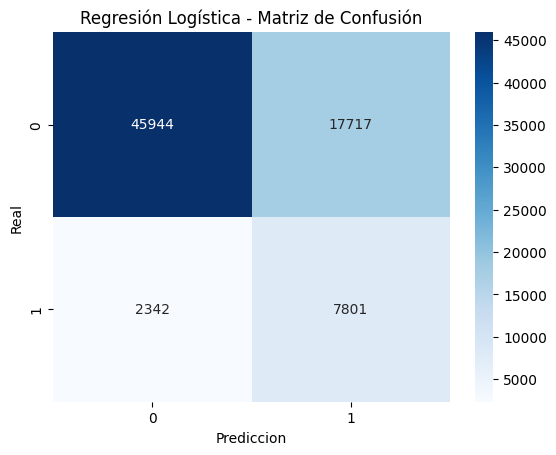

In [15]:
# === Probabilidades y baseline ===
y_proba = pipe_reglog.predict_proba(X_test)[:, 1]
y_pred = pipe_reglog.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"Regresión Logística - Matriz de Confusión")
plt.show()



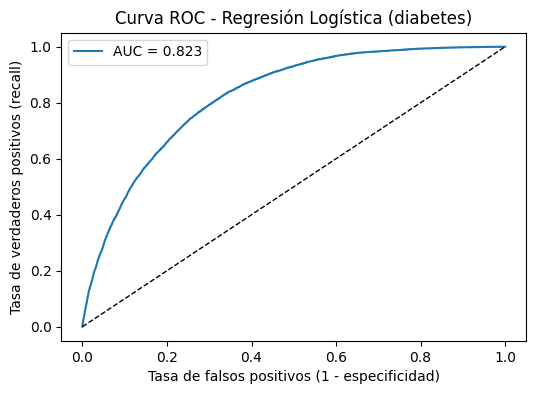

In [16]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - Regresión Logística (diabetes)")
plt.legend()
plt.show()


In [17]:
result_logreg = {
    "Modelo": "Regresión Logística",
    "AUC": roc_auc_score(y_test, y_proba),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "train_score": train_score,
    "test_score": test_score,
    "train_time": train_time
}

## **Modelo de ``KNN_NeighborsClassifier``**

In [18]:
pipe_knn= Pipeline(steps=[
    ('prep', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

In [19]:
start_time = time.time()
pipe_knn.fit(X_train, y_train)
train_time = time.time() - start_time   

In [20]:
train_score = pipe_knn.score(X_train, y_train)
test_score = pipe_knn.score(X_test, y_test) 
print("Training set score: {:.3f}".format(train_score))
print("Test set score: {:.3f}".format(test_score))

Training set score: 0.885
Test set score: 0.851


== Métricas con threshold ==
Accuracy: 0.8514985637634817

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92     63661
           1       0.39      0.14      0.21     10143

    accuracy                           0.85     73804
   macro avg       0.63      0.55      0.56     73804
weighted avg       0.81      0.85      0.82     73804



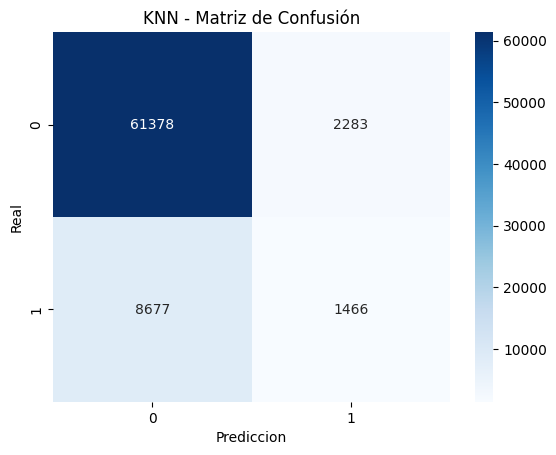

In [21]:
y_proba = pipe_knn.predict_proba(X_test)[:, 1]
y_pred = pipe_knn.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"KNN - Matriz de Confusión")
plt.show()


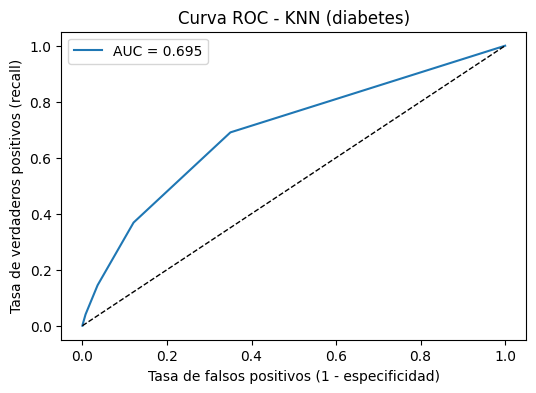

In [22]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - KNN (diabetes)")
plt.legend()
plt.show()


In [23]:
result_knn = {
    "Modelo": "Knn",
    "AUC": roc_auc_score(y_test, y_proba),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "train_score": train_score,
    "test_score": test_score,
    "train_time": train_time
}

## **Modelo de ``Naive Bayes``**

In [24]:
from sklearn.naive_bayes import GaussianNB

pipe_nb = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", GaussianNB())
])

In [25]:
start_time = time.time()
pipe_nb.fit(X_train, y_train)
train_time = time.time() - start_time   

In [26]:
train_score = pipe_nb.score(X_train, y_train)
test_score = pipe_nb.score(X_test, y_test) 
print("Training set score: {:.3f}".format(train_score))
print("Test set score: {:.3f}".format(test_score))  

Training set score: 0.724
Test set score: 0.725


== Métricas con threshold ==
Accuracy: 0.7245542247032681

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.73      0.82     63661
           1       0.29      0.70      0.41     10143

    accuracy                           0.72     73804
   macro avg       0.61      0.71      0.62     73804
weighted avg       0.85      0.72      0.76     73804



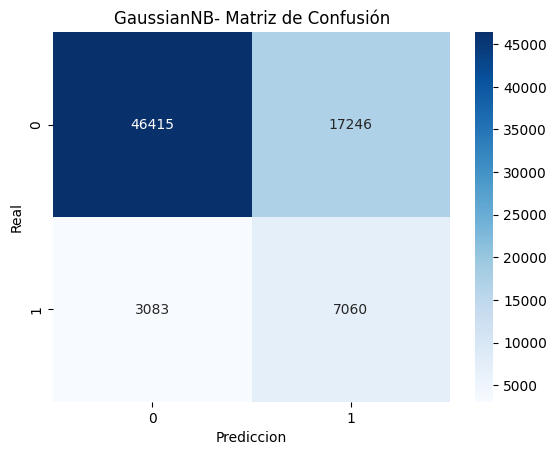

In [27]:
y_proba = pipe_nb.predict_proba(X_test)[:, 1]
y_pred = pipe_nb.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"GaussianNB- Matriz de Confusión")
plt.show()

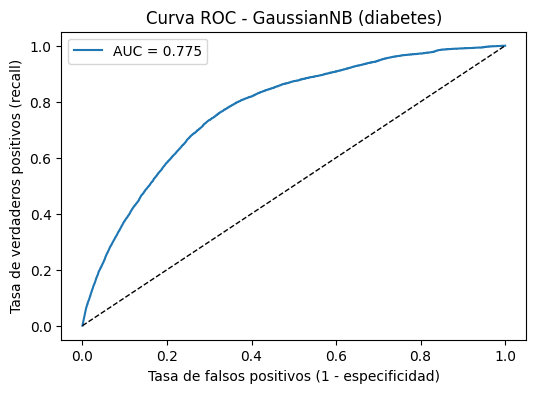

In [28]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - GaussianNB (diabetes)")
plt.legend()
plt.show()


In [29]:
result_nb = {
    "Modelo": "Naive Bayes",
    "AUC": roc_auc_score(y_test, y_proba),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "train_score": train_score,
    "test_score": test_score,
    "train_time": train_time
}

## **Modelo de ``DecisionTreeClassifier``**

In [30]:
from sklearn.tree import DecisionTreeClassifier

pipe_tree = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        class_weight="balanced",
        random_state=42
    ))
])

In [31]:
start_time = time.time()
pipe_tree.fit(X_train, y_train)
train_time = time.time() - start_time

In [32]:
train_score = pipe_tree.score(X_train, y_train)
test_score = pipe_tree.score(X_test, y_test)
print("Training set score: {:.3f}".format(train_score))
print("Test set score: {:.3f}".format(test_score))

Training set score: 0.999
Test set score: 0.800


== Métricas con threshold ==
Accuracy: 0.8004850685599697

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88     63661
           1       0.27      0.26      0.27     10143

    accuracy                           0.80     73804
   macro avg       0.58      0.57      0.58     73804
weighted avg       0.80      0.80      0.80     73804



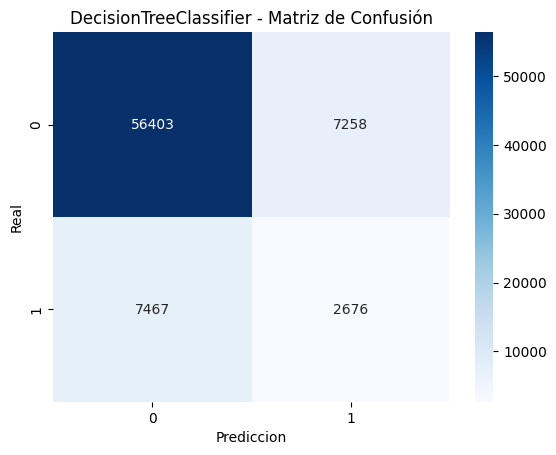

In [33]:
y_proba_tree = pipe_tree.predict_proba(X_test)[:, 1]
y_pred_tree = pipe_tree.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred_tree == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred_tree))

cm = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"DecisionTreeClassifier - Matriz de Confusión")
plt.show()

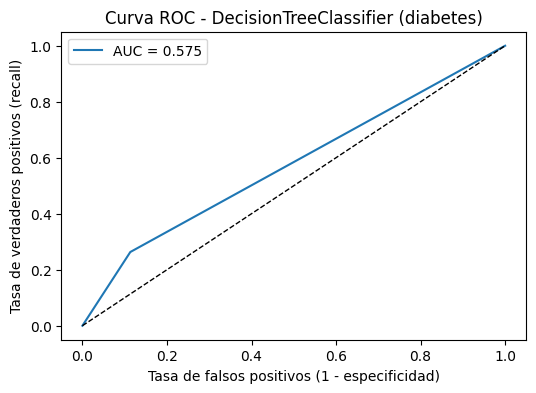

In [34]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba_tree)
roc_auc = roc_auc_score(y_test, y_proba_tree)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - DecisionTreeClassifier (diabetes)")
plt.legend()
plt.show()

In [35]:
result_tree = {
    "Modelo": "Desicion Tree",
    "AUC": roc_auc_score(y_test, y_proba),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
     "train_score": train_score,
    "test_score": test_score,
    "train_time": train_time
}

## **Modelo de ``RandomForestClassifier``**

In [36]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])


In [37]:
start_time = time.time()
pipe_rf.fit(X_train, y_train)
train_time = time.time() - start_time

In [38]:
train_score = pipe_rf.score(X_train, y_train)
test_score = pipe_rf.score(X_test, y_test)
print("Training set score: {:.3f}".format(train_score))
print("Test set score: {:.3f}".format(test_score))

Training set score: 1.000
Test set score: 0.864


== Métricas con threshold ==
Accuracy: 0.8639504633895182

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.99      0.93     63661
           1       0.53      0.08      0.14     10143

    accuracy                           0.86     73804
   macro avg       0.70      0.54      0.54     73804
weighted avg       0.82      0.86      0.82     73804



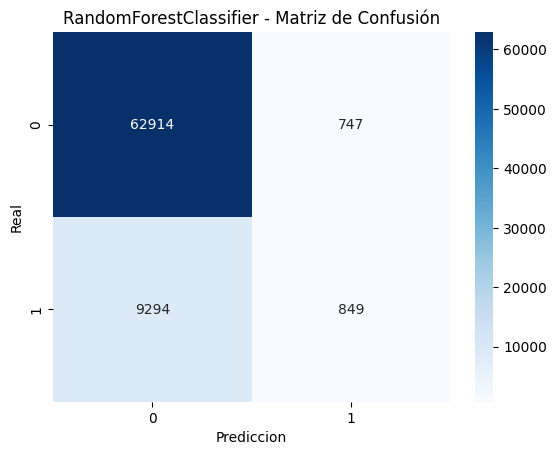

In [39]:
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]
y_pred_rf = pipe_rf.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred_rf == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"RandomForestClassifier - Matriz de Confusión")
plt.show()

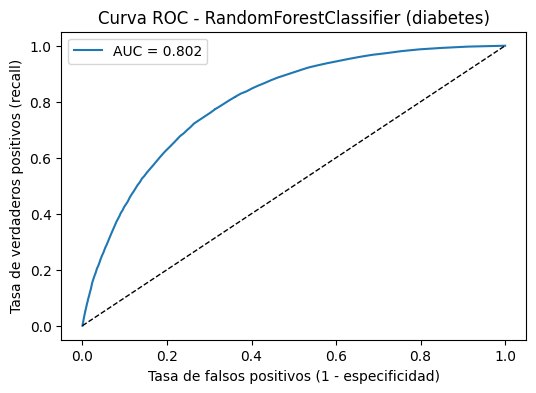

In [40]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc = roc_auc_score(y_test, y_proba_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - RandomForestClassifier (diabetes)")
plt.legend()
plt.show()

In [41]:
result_rf = {
    "Modelo": "Random Forest",
    "AUC": roc_auc_score(y_test, y_proba),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "train_score": train_score,
    "test_score": test_score,
    "train_time": train_time
}

## **Modelo de ``XGBClassifier``**

In [42]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", XGBClassifier(
        tree_method="hist",
        eval_metric="logloss",
        use_label_encoder=False,
        learning_rate=0.1,
        n_estimators=300,
        max_depth=5,
        random_state=42
    ))
])

In [43]:
start_time = time.time()
pipe_xgb.fit(X_train, y_train)
train_time = time.time() - start_time

c:\Users\franc\anaconda3\envs\ml_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:11:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [44]:
train_score = pipe_xgb.score(X_train, y_train)
test_score = pipe_xgb.score(X_test, y_test)
print("Training set score: {:.3f}".format(train_score))
print("Test set score: {:.3f}".format(test_score))

Training set score: 0.874
Test set score: 0.866


== Métricas con threshold ==
Accuracy: 0.8660370711614547

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93     63661
           1       0.55      0.14      0.22     10143

    accuracy                           0.87     73804
   macro avg       0.71      0.56      0.57     73804
weighted avg       0.83      0.87      0.83     73804



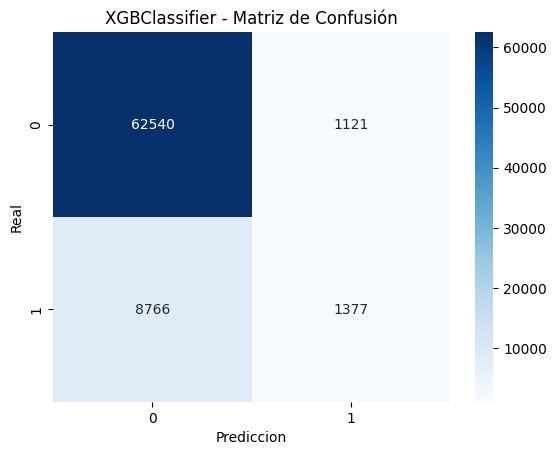

In [45]:
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb= pipe_xgb.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred_xgb == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"XGBClassifier - Matriz de Confusión")
plt.show()

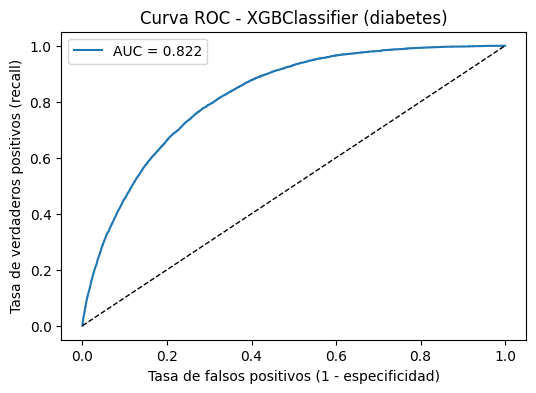

In [46]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
roc_auc = roc_auc_score(y_test, y_proba_xgb)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - XGBClassifier (diabetes)")
plt.legend()
plt.show()

In [47]:
result_xgb = {
    "Modelo": "XGBoost",
    "AUC": roc_auc_score(y_test, y_proba),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "train_score": train_score,
    "test_score": test_score,
    "train_time": train_time
}

## **Modelo de ``LinearSVC``**

In [48]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

pipe_svm = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", CalibratedClassifierCV(LinearSVC(max_iter=5000, class_weight='balanced'), cv=5))
])

In [49]:
start_time
pipe_svm.fit(X_train, y_train)
train_time = time.time() - start_time

In [50]:
train_score = pipe_svm.score(X_train, y_train)
test_score = pipe_svm.score(X_test, y_test)
print("Training set score: {:.3f}".format(train_score))
print("Test set score: {:.3f}".format(test_score))

Training set score: 0.866
Test set score: 0.866


== Métricas con threshold ==
Accuracy: 0.8661996639748523

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93     63661
           1       0.55      0.15      0.23     10143

    accuracy                           0.87     73804
   macro avg       0.71      0.56      0.58     73804
weighted avg       0.83      0.87      0.83     73804



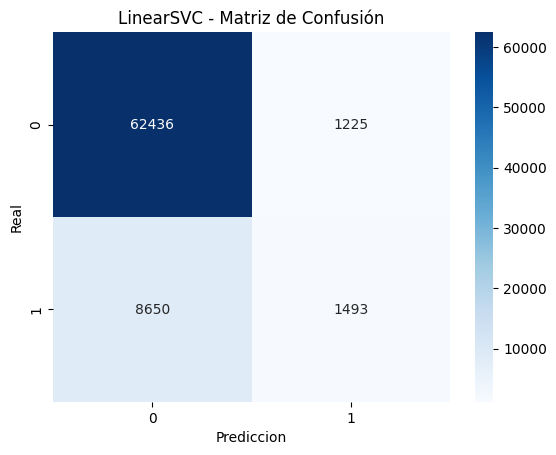

In [51]:
y_proba_svm = pipe_svm.predict_proba(X_test)[:, 1]
y_pred_svm= pipe_svm.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred_svm == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"LinearSVC - Matriz de Confusión")
plt.show()

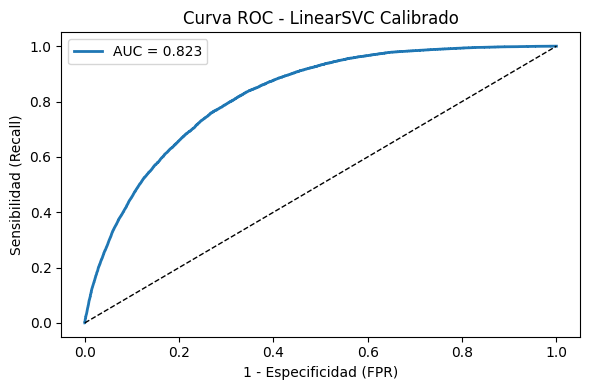

In [52]:

fpr, tpr, _ = roc_curve(y_test, y_proba_svm)
roc_auc = roc_auc_score(y_test, y_proba_svm)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0,1], [0,1], "k--", linewidth=1)
plt.xlabel("1 - Especificidad (FPR)")
plt.ylabel("Sensibilidad (Recall)")
plt.title("Curva ROC - LinearSVC Calibrado")
plt.legend()
plt.tight_layout()
plt.show()


In [53]:
result_svm = {
    "Modelo": "Linear SVC",
    "AUC": roc_auc_score(y_test, y_proba),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "train_score": train_score,
    "test_score": test_score,
    "train_time": train_time
}

## **Tebla Comparativa Benchmark**

In [54]:
df_benchmark = pd.DataFrame([
    result_logreg,
    result_knn,
    result_nb,
    result_tree,
    result_rf,
    result_xgb,
    result_svm
]).sort_values(by='AUC', ascending=False)

display(df_benchmark)

,Modelo,AUC,F1,Recall,Accuracy,train_score,test_score,train_time
0,Regresión Logística,0.823031,0.437509,0.769102,0.728213,0.727645,0.728213,3.114944
2,Naive Bayes,0.775327,0.409881,0.696047,0.724554,0.723522,0.724554,1.277405
3,Desicion Tree,0.775327,0.409881,0.696047,0.724554,0.999483,0.800485,3.610565
5,XGBoost,0.775327,0.409881,0.696047,0.724554,0.873973,0.866037,3.043539
4,Random Forest,0.775327,0.409881,0.696047,0.724554,0.999518,0.863950,14.414065
6,Linear SVC,0.775327,0.409881,0.696047,0.724554,0.866110,0.866200,16.645289
1,Knn,0.695249,0.211057,0.144533,0.851499,0.885023,0.851499,1.149506
